In [2]:
!pip install albumentations -q

In [3]:
!pip install timm -U -q
!pip install urllib3==1.25.4 -q
!pip install boto3 -U -q

In [54]:
import albumentations as A
import albumentations.augmentations.functional as F

import copy
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import pickle
import timm
import torch
import torchvision as tv
import torch.nn as nn
import json
import boto3
from io import BytesIO
from io import StringIO
from urllib.parse import urlparse
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import GroupKFold, KFold
import gc
from sklearn.metrics import (
    accuracy_score, 
    confusion_matrix,
    f1_score, 
    precision_score, 
    recall_score,
    roc_auc_score
)
from torch.cuda.amp import GradScaler
from torch.cuda.amp import autocast
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import time
import seaborn as sns


In [5]:
client = boto3.client("s3")

def list_all_objects_in_s3(bucketName, prefixName=None):
    """Get a list of objects in an S3 bucket path.
    @params:
    bucketName : s3 bucket 
    prefixName : s3 prefix to bucket
    returns : list of objects in s3 path
    [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}"]
    """
    if prefixName:
        resp = client.list_objects_v2(Bucket=bucketName, StartAfter=prefixName)
    else:
        resp = client.list_objects_v2(Bucket=bucketName)
    list_of_files=[]
    for obj in resp['Contents']:
        files = bucketName+'/'+obj['Key']
        if prefixName:
            if prefixName in files:
                if prefixName!=files:
                    list_of_files.append(files)
        else:
            list_of_files.append(files)
    return list_of_files

def from_s3_npy(s3_uri: str):
    """
    @params 
    data : file content 
    s3_uri : s3 file path along with name [example of S3 bucket with prefix f"s3://{bucketName}/{prefix}/{fileName.npy}"]
    """
    try:
        bytes_ = BytesIO()
        parsed_s3 = urlparse(s3_uri)
        client.download_fileobj(
            Fileobj=bytes_, Bucket=parsed_s3.netloc, Key=parsed_s3.path[1:]
        )
        bytes_.seek(0)
        np_data=np.load(bytes_, allow_pickle=True)
    
    except Exception as e: # work on python 3.x
        print('Failed to read numpy array from S3: '+ str(e))
    return np_data

s3 = boto3.resource("s3")
def read_file_from_s3(bucket, file):
    try:
        obj = s3.Object(bucket, file)
        data = obj.get()["Body"]
        
    except Exception as e: # work on python 3.x
        print("Failed to read file from S3: "+ str(e))
    return data.read().decode(encoding="utf-8")

In [6]:
train = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "train_annotations.csv")))
valid = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "val_annotations.csv")))
test = pd.read_csv(StringIO(read_file_from_s3("master-annotation-files", "test_annotations.csv")))


In [7]:
train = train[train["sl"] <= 160]
valid = valid[valid["sl"] <= 160]
test = test[test["sl"] <= 160]

In [8]:
train["image"] = train[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
valid["image"] = valid[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)
test["image"] = test[["scan_id", "sl"]].astype(str).agg("_".join, axis=1)


In [9]:
train

,image_id,category_id,tissue_id,bbox,confidence,labeler,category,supercat_id,supercategory,tissues,file_name,msp_id,msp_file_name,scan_id,subject_id,split,sl,2d_bbox,yolo_bbox,image
0,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,54,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_54
1,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,55,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_55
2,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,56,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_56
3,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,57,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_57
4,31,3,1,"[330.0, 232.0, 54.0, 5.0, 19.0, 10.0]",3.0,1,Meniscal Tear (Radial),1,Meniscal Tear,Meniscus,MTR_104.h5,0000025_V00,0000025_V00.h5,MTR_104,25,train,58,"[232.0, 330.0, 19.0, 5.0]","[0.4716796875, 0.6494140625, 0.037109375, 0.00...",MTR_104_58
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7834,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,102,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_102
7835,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,103,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_103
7836,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,104,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_104
7837,29,16,-1,"[186.0, 117.0, 49.0, 163.0, 50.0, 58.0]",3.0,2,Effusion,4,Effusion,NaN,MTR_101.h5,0000111_V00,0000111_V00.h5,MTR_101,111,train,105,"[117.0, 186.0, 50.0, 163.0]","[0.27734375, 0.5224609375, 0.09765625, 0.31835...",MTR_101_105


In [10]:
train2 = train
valid2 = valid
test2 = test

In [11]:
train2 = pd.get_dummies(train.supercategory)
valid2 = pd.get_dummies(valid.supercategory)
test2 = pd.get_dummies(test.supercategory)

In [12]:
train = pd.concat([train, train2], axis=1)
valid = pd.concat([valid, valid2], axis=1)
test = pd.concat([test, test2], axis=1)

In [13]:
train_set = train.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]
valid_set = valid.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]
test_set = test.loc[:, ["image", "Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]]

In [14]:
train_cv = pd.concat([train_set, valid_set])

In [15]:
train_cv.shape

(11013, 5)

In [16]:
train_cv = train_cv.drop_duplicates()

In [17]:
train_cv.shape

(9116, 5)

In [18]:
train_cv[train_cv["image"] == "MTR_105_56"]

,image,Cartilage Lesion,Effusion,Ligament Tear,Meniscal Tear
66,MTR_105_56,0,1,0,0
161,MTR_105_56,1,0,0,0


In [19]:
train_cv = train_cv.groupby(["image"]).max().reset_index()

In [20]:
train_cv.shape

(6160, 5)

In [21]:
train_cv

,image,Cartilage Lesion,Effusion,Ligament Tear,Meniscal Tear
0,MTR_001_77,0,0,1,0
1,MTR_001_78,0,0,1,0
2,MTR_001_79,0,0,1,0
3,MTR_001_80,0,0,1,0
4,MTR_001_81,0,0,1,0
...,...,...,...,...,...
6155,MTR_251_95,1,0,0,0
6156,MTR_251_96,1,0,0,0
6157,MTR_251_97,1,0,0,0
6158,MTR_251_98,1,0,0,0


### Effusion Class

In [22]:
train_effusion = pd.DataFrame(train_cv[["image", "Effusion"]])
train_effusion.loc[train_effusion["Effusion"] == 0, "Not Effusion"] = 1
train_effusion = train_effusion.fillna(0)
train_effusion.sum(axis = 0)

image           MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Effusion                                                     4109
Not Effusion                                               2051.0
dtype: object

In [23]:
train_effusion = train_effusion.drop(train_effusion[train_effusion["Effusion"] == 1].sample(frac = .5).index)
train_effusion.sum(axis = 0)

image           MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Effusion                                                     2055
Not Effusion                                               2051.0
dtype: object

In [24]:
train_effusion = train_effusion.reset_index()
train_effusion = train_effusion.drop("index", axis = 1)


In [96]:
test_effusion = pd.DataFrame(test_set[["image", "Effusion"]])
test_effusion.loc[test_effusion["Effusion"] == 0, "Not Effusion"] = 1
test_effusion = test_effusion.fillna(0)
test_effusion.sum(axis = 0)

image           MTR_173_20MTR_173_21MTR_173_22MTR_173_23MTR_17...
Effusion                                                     2603
Not Effusion                                               2693.0
dtype: object

### Cartilage Lesion

In [25]:
train_cl = pd.DataFrame(train_cv[["image", "Cartilage Lesion"]])
train_cl.loc[train_cl["Cartilage Lesion"] == 0, "Not Cartilage Lesion"] = 1
train_cl = train_cl.fillna(0.0)
train_cl.sum(axis = 0)

image                   MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Cartilage Lesion                                                     3053
Not Cartilage Lesion                                               3107.0
dtype: object

In [103]:
test_cl = pd.DataFrame(test_set[["image", "Cartilage Lesion"]])
test_cl.loc[test_cl["Cartilage Lesion"] == 0, "Not Cartilage Lesion"] = 1
test_cl = test_cl.fillna(0.0)
test_cl.sum(axis = 0)

image                   MTR_173_20MTR_173_21MTR_173_22MTR_173_23MTR_17...
Cartilage Lesion                                                     1696
Not Cartilage Lesion                                               3600.0
dtype: object

### Ligament Tear

In [26]:
train_lt = pd.DataFrame(train_cv[["image", "Ligament Tear"]])
train_lt.loc[train_lt["Ligament Tear"] == 0, "Not Ligament Tear"] = 1
train_lt = train_lt.fillna(0.0)
train_lt.sum(axis = 0)

image                MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Ligament Tear                                                      518
Not Ligament Tear                                               5642.0
dtype: object

In [27]:
train_lt = train_lt.drop(train_lt[train_lt["Not Ligament Tear"] == 1].sample(frac = .9).index)
train_lt.sum(axis = 0)

image                MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Ligament Tear                                                      518
Not Ligament Tear                                                564.0
dtype: object

In [28]:
train_lt = train_lt.reset_index()
train_lt = train_lt.drop("index", axis = 1)

In [101]:
test_lt = pd.DataFrame(test_set[["image", "Ligament Tear"]])
test_lt.loc[test_lt["Ligament Tear"] == 0, "Not Ligament Tear"] = 1
test_lt = test_lt.fillna(0.0)
test_lt.sum(axis = 0)

image                MTR_173_20MTR_173_21MTR_173_22MTR_173_23MTR_17...
Ligament Tear                                                      306
Not Ligament Tear                                               4990.0
dtype: object

### Meniscal Tear

In [29]:
train_mt = pd.DataFrame(train_cv[["image", "Meniscal Tear"]])
train_mt.loc[train_mt["Meniscal Tear"] == 0, "Not Meniscal Tear"] = 1
train_mt = train_mt.fillna(0.0)
train_mt.sum(axis = 0)

image                MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Meniscal Tear                                                     1436
Not Meniscal Tear                                               4724.0
dtype: object

In [30]:
train_mt = train_mt.drop(train_mt[train_mt["Not Meniscal Tear"] == 1].sample(frac = .7).index)
train_mt.sum(axis = 0)

image                MTR_001_77MTR_001_78MTR_001_82MTR_001_83MTR_00...
Meniscal Tear                                                     1436
Not Meniscal Tear                                               1417.0
dtype: object

In [31]:
train_mt = train_mt.reset_index()
train_mt = train_mt.drop("index", axis = 1)

In [102]:
test_mt = pd.DataFrame(test_set[["image", "Meniscal Tear"]])
test_mt.loc[test_mt["Meniscal Tear"] == 0, "Not Meniscal Tear"] = 1
test_mt = test_mt.fillna(0.0)
test_mt.sum(axis = 0)

image                MTR_173_20MTR_173_21MTR_173_22MTR_173_23MTR_17...
Meniscal Tear                                                      691
Not Meniscal Tear                                               4605.0
dtype: object

In [22]:
train_cv_no_effusion = train_cv.loc[:, ["image", "Cartilage Lesion", "Ligament Tear", "Meniscal Tear"]].reset_index()
train_cv_no_effusion = train_cv_no_effusion.drop("index", axis = 1)


In [23]:
train_cv_no_effusion["None of Above"] = np.where((train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0), 1, 0)


In [24]:
train_cv_no_effusion.sum(axis = 0)

image               MTR_001_77MTR_001_78MTR_001_79MTR_001_80MTR_00...
Cartilage Lesion                                                 3053
Ligament Tear                                                     518
Meniscal Tear                                                    1436
None of Above                                                    2208
dtype: object

In [25]:
train_cv_no_effusion["Cartilage Lesion"] = train_cv_no_effusion["Cartilage Lesion"].astype("float")
train_cv_no_effusion["Ligament Tear"] = train_cv_no_effusion["Ligament Tear"].astype("float")
train_cv_no_effusion["Meniscal Tear"] = train_cv_no_effusion["Meniscal Tear"].astype("float")
train_cv_no_effusion["None of Above"] = train_cv_no_effusion["None of Above"].astype("float")



In [38]:
train_cv_no_effusion.shape[0]

6160

In [37]:
# class count

print("Cartilage Lesion")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])

print("Ligament Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])

print("Meniscal Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 1)].shape[0])

print("Cartilage Lesion and Ligament Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])

print("Cartilage Lesion and Meniscal Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 1)].shape[0])

print("Meniscal Tear and Ligament Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 1)].shape[0])

print("None of Above")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])


Cartilage Lesion
2040
Ligament Tear
250
Meniscal Tear
623
Cartilage Lesion and Ligament Tear
226
Cartilage Lesion and Meniscal Tear
771
Meniscal Tear and Ligament Tear
26
None of Above
2208


In [ ]:
# sample the dataset so that each class is more balanced

train_cv_no_effusion = train_cv_no_effusion.drop(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0)].sample(frac = .8).index)

In [43]:
train_cv_no_effusion = train_cv_no_effusion.drop(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0)].sample(frac = .8).index)

In [44]:
# class count

print("Cartilage Lesion")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])

print("Ligament Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])

print("Meniscal Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 1)].shape[0])

print("Cartilage Lesion and Ligament Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])

print("Cartilage Lesion and Meniscal Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 1) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 1)].shape[0])

print("Meniscal Tear and Ligament Tear")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 1) & (train_cv_no_effusion["Meniscal Tear"] == 1)].shape[0])

print("None of Above")
print(train_cv_no_effusion[(train_cv_no_effusion["Cartilage Lesion"] == 0) & (train_cv_no_effusion["Ligament Tear"] == 0) & (train_cv_no_effusion["Meniscal Tear"] == 0)].shape[0])


Cartilage Lesion
408
Ligament Tear
250
Meniscal Tear
623
Cartilage Lesion and Ligament Tear
226
Cartilage Lesion and Meniscal Tear
771
Meniscal Tear and Ligament Tear
26
None of Above
442


In [46]:
train_cv_no_effusion = train_cv_no_effusion.reset_index()
train_cv_no_effusion = train_cv_no_effusion.drop("index", axis = 1)

In [47]:
train_cv_no_effusion

,image,Cartilage Lesion,Ligament Tear,Meniscal Tear,None of Above,split
0,MTR_001_77,0.0,1.0,0.0,0.0,4.0
1,MTR_001_78,0.0,1.0,0.0,0.0,4.0
2,MTR_001_79,0.0,1.0,0.0,0.0,0.0
3,MTR_001_80,0.0,1.0,0.0,0.0,1.0
4,MTR_001_81,0.0,1.0,0.0,0.0,2.0
...,...,...,...,...,...,...
2757,MTR_251_58,0.0,0.0,1.0,0.0,4.0
2758,MTR_251_59,0.0,0.0,1.0,0.0,4.0
2759,MTR_251_60,0.0,0.0,1.0,0.0,0.0
2760,MTR_251_61,0.0,0.0,1.0,0.0,1.0


In [ ]:
timm.list_models()

In [32]:
# Global variables
N_FOLDS = 3
MAX_LR = 2.0e-4
SAVE_CHECKPOINT_EVERY_STEP = 2000
CHECKPOINT_PATH = "/home/ec2-user/SageMaker/models"
PREDICT_MAX_BATCHES = 1e9
MAX_TRAIN_BATCHES = 10000
EPOCHS = 10
BACKBONE = "efficientnet_b1"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    BATCH_SIZE = 8
else:
    BATCH_SIZE = 2

In [33]:
# CV splits
split = GroupKFold(N_FOLDS)
df_list = [train_effusion, train_cl, train_lt, train_mt]

for train_df in df_list:
    for k, (_, test_idx) in enumerate(split.split(train_df, groups=train_df.image)):
        train_df.loc[test_idx, "split"] = k

In [34]:
train_lt.sample(5)

,image,Ligament Tear,Not Ligament Tear,split
742,MTR_189_70,0,1.0,2.0
46,MTR_016_104,0,1.0,0.0
739,MTR_186_43,0,1.0,0.0
786,MTR_201_48,0,1.0,1.0
1029,MTR_236_118,0,1.0,0.0


In [33]:
from_s3_npy("s3://skm-dataset-echo1/MTR_104_58.npy")

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [89]:
class LesionDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Cartilage Lesion", "Effusion", "Ligament Tear", "Meniscal Tear"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)

In [36]:
class CartilageLesionDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Cartilage Lesion", "Not Cartilage Lesion"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)
    
class LigamentTearDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Ligament Tear", "Not Ligament Tear"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)
    
class MeniscalTearDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Meniscal Tear", "Not Meniscal Tear"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)
    
class EffusionDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Effusion", "Not Effusion"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)

In [39]:
# Image augmentations
train_transform = A.Compose([
    A.GaussianBlur((3, 7), p=0.25),
    A.RandomRotate90(p=0.25),
    A.OneOf([
        A.MotionBlur(p=0.2),
        A.Blur(blur_limit=3, p=0.1),
    ], p=0.5),
    A.ShiftScaleRotate(shift_limit=0.0625, scale_limit=0.2, rotate_limit=45, interpolation=cv2.INTER_LINEAR, border_mode=cv2.BORDER_CONSTANT, p=0.25),
    A.OneOf([
        A.OpticalDistortion(p=0.3),
        A.GridDistortion(p=0.1),
    ], p=0.25),
    ToTensorV2(p=1.0)
])

valid_transform = A.Compose([
    ToTensorV2(p=1.0)
])
     

In [ ]:
# Check the dataset outputs
dataset_train = LesionDataset(train_cv_no_effusion, train_transform)
x, y = dataset_train[500]
print(x.shape, y.shape)

In [40]:
dataset_train_cl = CartilageLesionDataset(train_cl, train_transform)
x, y = dataset_train_cl[10]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([2])


In [41]:
dataset_train_lt = LigamentTearDataset(train_lt, train_transform)
x, y = dataset_train_lt[10]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([2])


In [42]:
dataset_train_mt = MeniscalTearDataset(train_mt, train_transform)
x, y = dataset_train_mt[10]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([2])


In [43]:
dataset_train_eff = EffusionDataset(train_effusion, train_transform)
x, y = dataset_train_eff[10]
print(x.shape, y.shape)

torch.Size([1, 512, 512]) torch.Size([2])


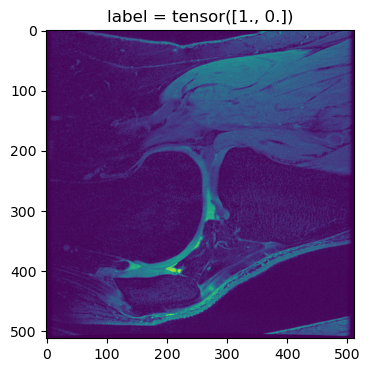

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
ax.imshow(np.transpose(x, (1, 2, 0)))
ax.set_title(f"label = {y}")
plt.show()

In [45]:
# Custom model class
class LesionModel(nn.Module):
    def __init__(self, backbone):
        super().__init__()
        self.model = timm.create_model(backbone, pretrained=True, in_chans=1, num_classes=2)

    def forward(self, x):
        x = self.model(x)
        return x

In [46]:
# Quick test of the model
print(BACKBONE)
model = LesionModel(BACKBONE)
print(model(torch.randn(1, 1, 512, 512)))
del model

efficientnet_b1
tensor([[ 0.2483, -1.9537]], grad_fn=<AddmmBackward0>)


In [47]:
def gc_collect():
    """Performs garbage removal after memory-intensive operations."""
    gc.collect()
    torch.cuda.empty_cache()
    
def load_model(model, path, device="cpu"):
    """Loads a model from a specified location.

    Args:
        model: An instance of the model class to load.
        path: A path to load model weights from.
        device: A device to place the model onto.

    Returns:
        model: The model with the loaded weights.
    """
    weights = torch.load(os.path.join(path), map_location=device)
    model.load_state_dict(weights)
    return model

def save_model(model, path):
    """Saves a model.

    Args:
        model: The model to save.
        path: The path to the saved model file.
    """
    torch.save(model.state_dict(), path)
    
def save_cm(df, path):
    df.to_csv(path, index=False)

In [48]:
def get_top_k_metrics(y_true, y_pred, k):
    """Retrieves the top-n predictions.

    Args:
        y_true: An array of the true sample labels.
        y_pred: An array of the predicted sample probabilities.
        k: The number of top class probabilities to consider.
    Returns:
        metrics: A dict of top-k metrics (accuracy, precision, recall, f1, confusion matrix)
    """
    y_true_labels = np.argmax(y_true, axis=1)
    sorted_pred = np.argsort(y_pred, axis=1, kind="mergesort")[:, ::-1][:, :k]
    hits = (y_true_labels == sorted_pred.T).any(axis=0).astype(np.uint8)
    accuracy = hits.mean()
    tp = np.array([hits[y_true_labels == i].sum() for i in range(2)])
    fn = np.array([((y_true_labels == i) & np.logical_not((sorted_pred == i).any(axis=1))).sum() for i in range(2)])
    fp = np.array([((y_true_labels != i) & (hits == 0) & (sorted_pred == i).any(axis=1)).sum() for i in range(2)])
    precision = tp / (tp + fp)
    recall = tp / (tp + fn)
    f2 = (1 + 2.0 ** 2) * precision * recall / (2.0 ** 2 * precision + recall)
    cm = np.array([[((y_true_labels == i) & (sorted_pred == j).any(axis=1)).sum() for j in range(2)] for i in range(2)])
    metrics = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f2": f2,
        "confusion_matrix": cm
    }
    return metrics

In [92]:
def evaluate_classification_model(
    model, 
    dataset, 
    max_batches, 
    device="cpu", 
    batch_size=2,
    shuffle=False
):
    """Evaluates a lesion classification model against a dataset.

    Args:
        model: A model to be evaluated.
        dataset: A dataset object containing images to evaluate the model with.
        max_batches: The number of batches to run the evaluation loop for. If the number of
            iterations exceeds max_batches, the loop will terminate.
        device: A device to run the evaluation loop on.
        batch_size: The number of images to process at the same time.
        shuffle: A boolean signifying whether or not to shuffle the dataset.

    Returns:
        loss: The average cross-entropy loss across all images in the dataset.
        roc_auc: The average ROC AUC score across all classes and images in the dataset.
        f1: The average F1 score across all classes and images in the dataset.
    """
    torch.manual_seed(42)
    model = model.to(device)
    model.eval()
    loader_test = torch.utils.data.DataLoader(
        dataset, 
        batch_size=batch_size, 
        shuffle=shuffle, 
        num_workers=os.cpu_count()
    )
    y_true = []
    y_pred = []
    total_loss = 0.0
    n = 0
    with torch.no_grad():
        with tqdm(loader_test) as loader_:
            for i, (x, y) in enumerate(loader_):
                x = x.to(device, dtype=torch.float)
                y = y.to(device)
                logits = model(x)
                #loss = nn.CrossEntropyLoss()(logits, y.float())
                loss = nn.BCEWithLogitsLoss()(logits, y.float())
                y_pred.append(torch.nn.functional.softmax(logits, dim=-1).cpu().numpy())
                y_true.append(y.cpu().numpy())
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n:.04f}")
                if i >= max_batches:
                    break
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    loss = total_loss / n
    roc_auc = roc_auc_score(y_true, y_pred, multi_class="ovr", average="macro")
    print("\n\n[EVALUATION METRICS]")
    print(f"Loss: {loss:.04f}")
    print(f"ROC AUC: {roc_auc:.04f}\n")
    for k in range(1, 2):
        metrics = get_top_k_metrics(y_true, y_pred, k)
        print(f"[k = {k}]")
        print(f"F2: {metrics['f2'].mean():.04f}")
        print(f"Precision: {metrics['precision'].mean():.04f}")
        print(f"Recall: {metrics['recall'].mean():.04f}")
        print(f"Accuracy: {metrics['accuracy'].mean():.04f}")
        if k == 1:
            cm = pd.DataFrame(metrics["confusion_matrix"], index=dataset.classes, columns=dataset.classes)
            print(f"Confusion Matrix:\n{cm}")
        print()
    return loss, cm

def train_classification_model(
    model,
    dataset_train,
    dataset_valid,
    path,
    path_cm,
    class_weights=None,
    batch_size=8,
    device="cpu",
    epochs=1,
    max_lr=2.0e-4
):
    """Trains a classification model.

    Args:
        model: The model to train.
        dataset_train: A training dataset.
        dataset_valid: A validation dataset.
        path: A path to save the model to.
        class_weights: The relative weight of each lesion class when computing the cross-entropy loss.
        batch_size: The number of images to process at the same time.
        device: A device to run the training loop on.

    Returns:
        model: The best model from the training loop.
    """
    torch.manual_seed(42)
    loader_train = torch.utils.data.DataLoader(
        dataset_train, 
        batch_size=batch_size, 
        shuffle=True, 
        num_workers=os.cpu_count(),
        pin_memory=True,
        timeout=120
    )
    optim = torch.optim.RAdam(model.parameters())
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optim, 
        max_lr=max_lr, 
        epochs=epochs,
        steps_per_epoch=len(loader_train),
        pct_start=0.3
    )
    model.train()
    if class_weights is not None:
        class_weights = torch.tensor(class_weights).to(device)
    scaler = GradScaler()
    best_loss = float("inf")
    best_cm = pd.DataFrame()
    best_model = copy.deepcopy(model)
    for epoch in range(epochs):
        print(f"[EPOCH {epoch + 1}/{epochs}]")
        with tqdm(loader_train) as loader_:
            total_loss = 0.0
            n = 0
            for i, (x, y) in enumerate(loader_):
                optim.zero_grad()
                with autocast():
                    x = x.to(device, dtype=torch.float)
                    y = y.to(device)
                    logits = model(x)
                    loss = nn.BCEWithLogitsLoss(weight=class_weights)(logits, y.float())
                    if np.isinf(loss.item()) or np.isnan(loss.item()):
                        print(f"Bad loss, skipping batch {i}")
                        del loss
                        gc_collect()
                        continue
                scaler.scale(loss).backward()
                scaler.step(optim)
                scaler.update()
                scheduler.step()
                total_loss += loss.item() * x.size(0)
                n += x.size(0)
                loader_.set_description(f"loss = {total_loss / n :.04f}")
        loss, cm = evaluate_classification_model(
            model, 
            dataset_valid, 
            max_batches=10000, 
            device=device, 
            batch_size=batch_size,
            shuffle=False
        )
        if loss < best_loss: 
            save_model(model, path)
            best_loss = loss
            best_model = copy.deepcopy(model)
            save_cm(cm, path_cm)
    return best_model

def predict_lesion(x, y, model, device, verbose=True):
    """Predicts the lesion class for a given image.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
        verbose: A boolean flag indicating whether or not to display additional information.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        logits = model(x)
        loss = nn.BCEWithLogitsLoss()(logits, y.float())
        y_pred = torch.nn.functional.softmax(logits, dim=-1)[0]
        loss += loss.item()
    if verbose:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
        ax.imshow(np.transpose(x[0].cpu().numpy(), (1, 2, 0)))
        print(f"y_true = {y.cpu().numpy()[0]}")
        print(f"y_pred = {np.around(y_pred.cpu().numpy(), 3)}")


def visualize_features(x, y, model, device, k=1):
    """Visualizes the learned kernel features of a CNN model.

    Args:
        x: An image to predict lesions for.
        y: The true label for the image.
        model: A model to use to make predictions.
        device: A device to evaluate on.
    """
    x = x.to(device, dtype=torch.float)[None, :]
    y = y.to(device)[None, :]
    model = model.to(device)
    model.eval()
    with torch.no_grad():
        layers = list(model.model.children())
        f = x
        for i in range(k):
            layer = layers[i]
            f = layer(f)
    fig, axs = plt.subplots(nrows=8, ncols=4, figsize=(4 * 4, 8 * 4))
    for i in range(8):
        for j in range(4):
            ax = axs[i, j]
            ax.imshow(f[0, i + j].cpu().numpy())
            ax.set_title(i + j)

### Cartilage Lesion


In [64]:
# Training loop
t0 = time.time()
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, "cartilageLesion", f"cl_efficientnetb1-f{fold}.tph")
    path_cm = os.path.join(CHECKPOINT_PATH, "cartilageLesion", f"cm_cl_efficientnetb1-f{fold}.csv")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = CartilageLesionDataset(train_cl.query("split != @fold"), train_transform)
        dataset_valid = CartilageLesionDataset(train_cl.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                path_cm,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )
        
print(f"total training time: {time.time() - t0}")

[FOLD 1/3]
[EPOCH 1/10]


  0%|          | 0/514 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
loss = 0.8310: 100%|██████████| 257/257 [00:25<00:00,  9.90it/s]




[EVALUATION METRICS]
Loss: 0.8310
ROC AUC: 0.6939

[k = 1]
F2: 0.6393
Precision: 0.6393
Recall: 0.6393
Accuracy: 0.6392
Confusion Matrix:
                      Cartilage Lesion  Not Cartilage Lesion
Cartilage Lesion                   654                   363
Not Cartilage Lesion               378                   659

[EPOCH 2/10]


loss = 0.5568: 100%|██████████| 257/257 [00:25<00:00,  9.92it/s]




[EVALUATION METRICS]
Loss: 0.5568
ROC AUC: 0.8006

[k = 1]
F2: 0.7138
Precision: 0.7215
Recall: 0.7160
Accuracy: 0.7152
Confusion Matrix:
                      Cartilage Lesion  Not Cartilage Lesion
Cartilage Lesion                   811                   206
Not Cartilage Lesion               379                   658

[EPOCH 3/10]


...



[EVALUATION METRICS]
Loss: 0.2544
ROC AUC: 0.9783

[k = 1]
F2: 0.9313
Precision: 0.9314
Recall: 0.9314
Accuracy: 0.9313
Confusion Matrix:
                      Cartilage Lesion  Not Cartilage Lesion
Cartilage Lesion                   959                    62
Not Cartilage Lesion                79                   953

[EPOCH 9/10]


loss = 0.2720: 100%|██████████| 257/257 [00:22<00:00, 11.29it/s]




[EVALUATION METRICS]
Loss: 0.2720
ROC AUC: 0.9776

[k = 1]
F2: 0.9279
Precision: 0.9279
Recall: 0.9279
Accuracy: 0.9279
Confusion Matrix:
                      Cartilage Lesion  Not Cartilage Lesion
Cartilage Lesion                   953                    68
Not Cartilage Lesion                80                   952

[EPOCH 10/10]


loss = 0.2715: 100%|██████████| 257/257 [00:23<00:00, 11.17it/s]



[EVALUATION METRICS]
Loss: 0.2715
ROC AUC: 0.9778

[k = 1]
F2: 0.9269
Precision: 0.9269
Recall: 0.9269
Accuracy: 0.9269
Confusion Matrix:
                      Cartilage Lesion  Not Cartilage Lesion
Cartilage Lesion                   949                    72
Not Cartilage Lesion                78                   954

total training time: 3004.7310955524445


In [66]:
cm_cl = pd.read_csv("models/cartilageLesion/cm_cl_efficientnetb1-f2.csv")
cm_cl = cm_cl.rename(index = {0:"Cartilage Lesion", 1:"Not Cartilage Lesion"})

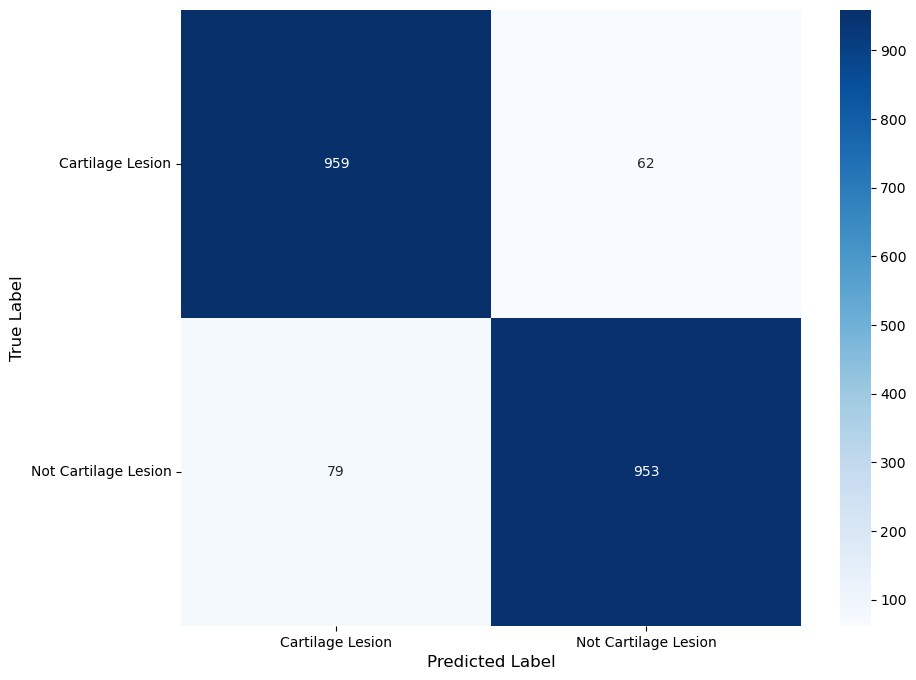

In [67]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(cm_cl, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Cartilage Lesion", "Not Cartilage Lesion"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

### Ligament Tear

In [68]:
# Training loop
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, "ligamentTear", f"lt_efficientnetb1-f{fold}.tph")
    path_cm = os.path.join(CHECKPOINT_PATH, "ligamentTear", f"cm_lt_efficientnetb1-f{fold}.csv")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = LigamentTearDataset(train_lt.query("split != @fold"), train_transform)
        dataset_valid = LigamentTearDataset(train_lt.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                path_cm,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )

[FOLD 1/3]
[EPOCH 1/10]


  0%|          | 0/91 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
loss = 1.2744: 100%|██████████| 46/46 [00:06<00:00,  7.37it/s]




[EVALUATION METRICS]
Loss: 1.2744
ROC AUC: 0.6271

[k = 1]
F2: 0.4617
Precision: 0.5462
Recall: 0.5141
Accuracy: 0.5291
Confusion Matrix:
                   Ligament Tear  Not Ligament Tear
Ligament Tear                 17                157
Not Ligament Tear             13                174

[EPOCH 2/10]


loss = 0.4490: 100%|██████████| 46/46 [00:06<00:00,  7.66it/s]




[EVALUATION METRICS]
Loss: 0.4490
ROC AUC: 0.8939

[k = 1]
F2: 0.8049
Precision: 0.8070
Recall: 0.8048
Accuracy: 0.8061
Confusion Matrix:
                   Ligament Tear  Not Ligament Tear
Ligament Tear                134                 40
Not Ligament Tear             30                157

[EPOCH 3/10]


...



[EVALUATION METRICS]
Loss: 0.1961
ROC AUC: 0.9853

[k = 1]
F2: 0.9414
Precision: 0.9419
Recall: 0.9413
Accuracy: 0.9417
Confusion Matrix:
                   Ligament Tear  Not Ligament Tear
Ligament Tear                162                 12
Not Ligament Tear              9                177

[EPOCH 9/10]


loss = 0.1989: 100%|██████████| 45/45 [00:07<00:00,  6.28it/s]




[EVALUATION METRICS]
Loss: 0.1989
ROC AUC: 0.9851

[k = 1]
F2: 0.9364
Precision: 0.9365
Recall: 0.9369
Accuracy: 0.9361
Confusion Matrix:
                   Ligament Tear  Not Ligament Tear
Ligament Tear                167                  7
Not Ligament Tear             16                170

[EPOCH 10/10]


loss = 0.1993: 100%|██████████| 45/45 [00:06<00:00,  7.18it/s]



[EVALUATION METRICS]
Loss: 0.1993
ROC AUC: 0.9851

[k = 1]
F2: 0.9364
Precision: 0.9365
Recall: 0.9369
Accuracy: 0.9361
Confusion Matrix:
                   Ligament Tear  Not Ligament Tear
Ligament Tear                167                  7
Not Ligament Tear             16                170



In [55]:
cm_lt = pd.read_csv("models/ligamentTear/cm_lt_efficientnetb1-f2.csv")
cm_lt = cm_lt.rename(index = {0:"Ligament Tear", 1:"Not Ligament Tear"})

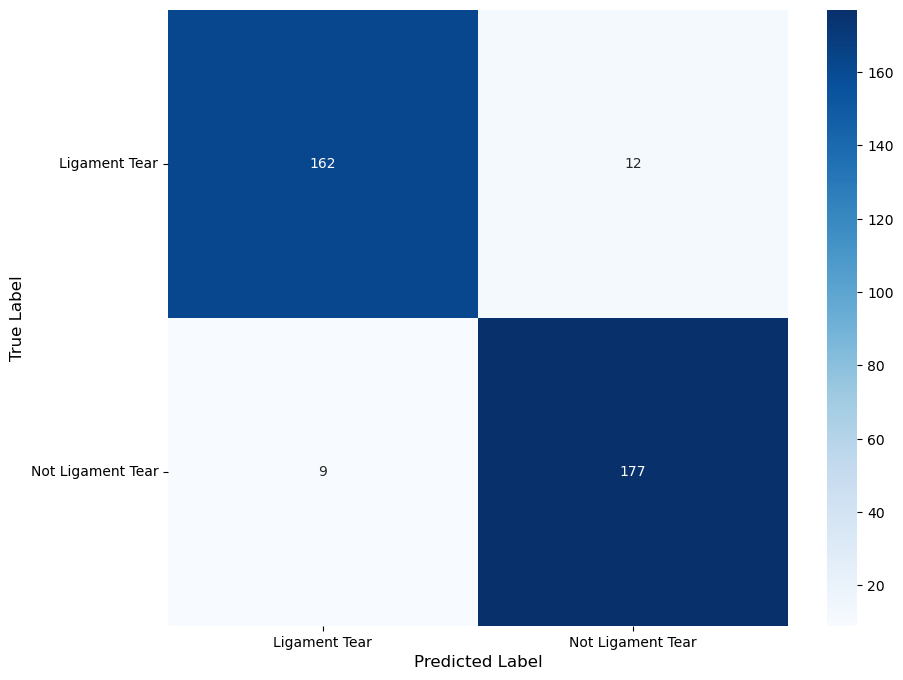

In [56]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(cm_lt, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Ligament Tear", "Not Ligament Tear"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

### Meniscal Tear

In [57]:
# Training loop
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, "meniscalTear", f"mt_efficientnetb1-f{fold}.tph")
    path_cm = os.path.join(CHECKPOINT_PATH, "meniscalTear", f"cm_mt_efficientnetb1-f{fold}.csv")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = MeniscalTearDataset(train_mt.query("split != @fold"), train_transform)
        dataset_valid = MeniscalTearDataset(train_mt.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                path_cm,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )

[FOLD 1/3]
[EPOCH 1/10]


  0%|          | 0/238 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
loss = 1.0563: 100%|██████████| 119/119 [00:13<00:00,  9.00it/s]




[EVALUATION METRICS]
Loss: 1.0563
ROC AUC: 0.5665

[k = 1]
F2: 0.5352
Precision: 0.5376
Recall: 0.5369
Accuracy: 0.5363
Confusion Matrix:
                   Meniscal Tear  Not Meniscal Tear
Meniscal Tear                285                186
Not Meniscal Tear            255                225

[EPOCH 2/10]


loss = 0.5843: 100%|██████████| 119/119 [00:12<00:00,  9.38it/s]




[EVALUATION METRICS]
Loss: 0.5843
ROC AUC: 0.8056

[k = 1]
F2: 0.7283
Precision: 0.7293
Recall: 0.7284
Accuracy: 0.7287
Confusion Matrix:
                   Meniscal Tear  Not Meniscal Tear
Meniscal Tear                329                142
Not Meniscal Tear            116                364

[EPOCH 3/10]


...



[EVALUATION METRICS]
Loss: 0.3290
ROC AUC: 0.9639

[k = 1]
F2: 0.8835
Precision: 0.8881
Recall: 0.8841
Accuracy: 0.8843
Confusion Matrix:
                   Meniscal Tear  Not Meniscal Tear
Meniscal Tear                446                 32
Not Meniscal Tear             78                395

[EPOCH 9/10]


loss = 0.3242: 100%|██████████| 119/119 [00:12<00:00,  9.27it/s]




[EVALUATION METRICS]
Loss: 0.3242
ROC AUC: 0.9656

[k = 1]
F2: 0.8878
Precision: 0.8924
Recall: 0.8883
Accuracy: 0.8885
Confusion Matrix:
                   Meniscal Tear  Not Meniscal Tear
Meniscal Tear                448                 30
Not Meniscal Tear             76                397

[EPOCH 10/10]


loss = 0.3300: 100%|██████████| 119/119 [00:12<00:00,  9.52it/s]



[EVALUATION METRICS]
Loss: 0.3300
ROC AUC: 0.9656

[k = 1]
F2: 0.8876
Precision: 0.8930
Recall: 0.8883
Accuracy: 0.8885
Confusion Matrix:
                   Meniscal Tear  Not Meniscal Tear
Meniscal Tear                450                 28
Not Meniscal Tear             78                395



In [62]:
cm_mt = pd.read_csv("models/meniscalTear/cm_mt_efficientnetb1-f2.csv")
cm_mt = cm_mt.rename(index = {0:"Meniscal Tear", 1:"Not Meniscal Tear"})

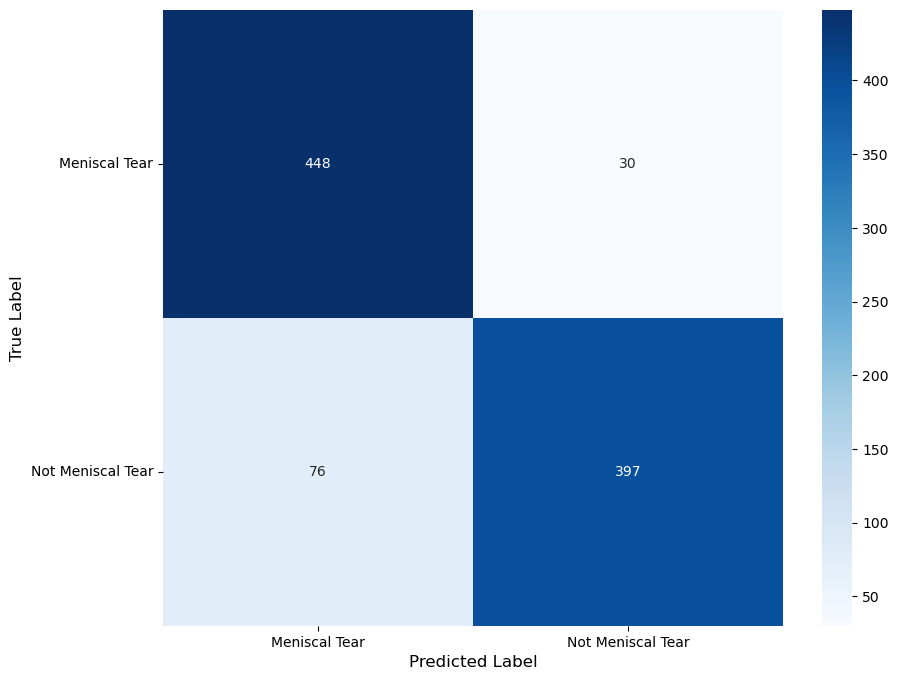

In [63]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(cm_mt, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Meniscal Tear", "Not Meniscal Tear"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

### Effusion

In [65]:
# Training loop
classification_models = []
for fold in range(N_FOLDS):
    print(f"[FOLD {fold + 1}/{N_FOLDS}]")
    path = os.path.join(CHECKPOINT_PATH, "Effusion", f"eff_efficientnetb1-f{fold}.tph")
    path_cm = os.path.join(CHECKPOINT_PATH, "Effusion", f"cm_eff_efficientnetb1-f{fold}.csv")
    # Load the models if they already exist
    if os.path.exists(path):
        print(f"Found cached version of {path}")
        classification_models.append(load_model(LesionModel(BACKBONE), path, DEVICE))
    else:
        gc_collect()
        dataset_train = EffusionDataset(train_effusion.query("split != @fold"), train_transform)
        dataset_valid = EffusionDataset(train_effusion.query("split == @fold"), valid_transform)
        model = LesionModel(BACKBONE).to(DEVICE)
        classification_models.append(
            train_classification_model(
                model,
                dataset_train,
                dataset_valid,
                path,
                path_cm,
                class_weights=None,
                batch_size=BATCH_SIZE,
                device=DEVICE,
                epochs=EPOCHS,
                max_lr=MAX_LR
            )
        )

[FOLD 1/3]
[EPOCH 1/10]


  0%|          | 0/343 [00:00<?, ?it/s]/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:139: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn("Detected call of `lr_scheduler.step()` before `optimizer.step()`. "
loss = 0.8548: 100%|██████████| 172/172 [00:17<00:00, 10.10it/s]




[EVALUATION METRICS]
Loss: 0.8548
ROC AUC: 0.6805

[k = 1]
F2: 0.6220
Precision: 0.6239
Recall: 0.6229
Accuracy: 0.6224
Confusion Matrix:
              Effusion  Not Effusion
Effusion           398           294
Not Effusion       223           454

[EPOCH 2/10]


loss = 0.4728: 100%|██████████| 172/172 [00:16<00:00, 10.32it/s]




[EVALUATION METRICS]
Loss: 0.4728
ROC AUC: 0.8746

[k = 1]
F2: 0.7719
Precision: 0.7836
Recall: 0.7746
Accuracy: 0.7736
Confusion Matrix:
              Effusion  Not Effusion
Effusion           472           220
Not Effusion        90           587

[EPOCH 3/10]


...



[EVALUATION METRICS]
Loss: 0.2130
ROC AUC: 0.9851

[k = 1]
F2: 0.9403
Precision: 0.9427
Recall: 0.9403
Accuracy: 0.9408
Confusion Matrix:
              Effusion  Not Effusion
Effusion           613            61
Not Effusion        20           674

[EPOCH 9/10]


loss = 0.2341: 100%|██████████| 171/171 [00:16<00:00, 10.59it/s]




[EVALUATION METRICS]
Loss: 0.2341
ROC AUC: 0.9850

[k = 1]
F2: 0.9394
Precision: 0.9426
Recall: 0.9395
Accuracy: 0.9401
Confusion Matrix:
              Effusion  Not Effusion
Effusion           609            65
Not Effusion        17           677

[EPOCH 10/10]


loss = 0.2344: 100%|██████████| 171/171 [00:16<00:00, 10.69it/s]



[EVALUATION METRICS]
Loss: 0.2344
ROC AUC: 0.9850

[k = 1]
F2: 0.9394
Precision: 0.9426
Recall: 0.9395
Accuracy: 0.9401
Confusion Matrix:
              Effusion  Not Effusion
Effusion           609            65
Not Effusion        17           677



In [66]:
cm_eff = pd.read_csv("models/Effusion/cm_eff_efficientnetb1-f2.csv")
cm_eff = cm_eff.rename(index = {0:"Effusion", 1:"Not Effusion"})

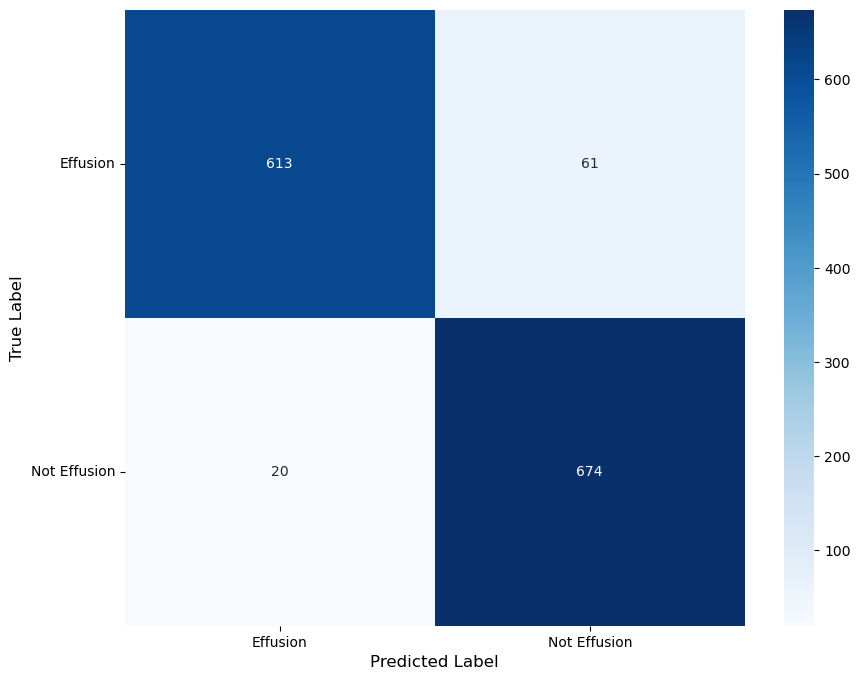

In [67]:
plt.figure(figsize = (10, 8))
p = sns.heatmap(cm_eff, cmap="Blues", annot=True, fmt="g")
p.set_yticklabels(labels = ["Effusion", "Not Effusion"], rotation=0)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.show()

In [69]:
test_set

,image,Cartilage Lesion,Effusion,Ligament Tear,Meniscal Tear
0,MTR_173_20,0,1,0,0
1,MTR_173_21,0,1,0,0
2,MTR_173_22,0,1,0,0
3,MTR_173_23,0,1,0,0
4,MTR_173_24,0,1,0,0
...,...,...,...,...,...
5291,MTR_158_137,0,1,0,0
5292,MTR_158_138,0,1,0,0
5293,MTR_158_139,0,1,0,0
5294,MTR_158_140,0,1,0,0


In [79]:
m_cl_path = os.path.join("models/" + "cartilageLesion/" + "cl_efficientnetb1-f2.tph")
m_lt_path = os.path.join("models/" + "ligamentTear/" + "lt_efficientnetb1-f2.tph")
m_mt_path = os.path.join("models/" + "meniscalTear/" + "mt_efficientnetb1-f2.tph")
m_eff_path = os.path.join("models/" + "Effusion/" + "eff_efficientnetb1-f2.tph")


In [110]:
m_path = [m_cl_path, m_lt_path, m_mt_path, m_eff_path]
dat_test = [test_cl, test_lt, test_mt, test_effusion]

In [112]:
class LesionTestDataset(torch.utils.data.Dataset):
    def __init__(self, df, transform=None):
        super().__init__()
        self.df = df
        self.transform = transform
        self.classes = ["Lesion", "Not Lesion"]
        
    def __getitem__(self, i):
        row = self.df.iloc[i]
        image_id = row.image
        img = from_s3_npy("s3://skm-dataset-echo1/" + image_id + ".npy")

        # Apply image transformations (if any)
        if self.transform is not None:
            x = self.transform(image=img)["image"]
        else:
            x = img

        # Labels
        y = torch.tensor(np.array([float(row[c]) for c in self.classes]), dtype=torch.float32)

        return x, y

    def __len__(self):
        return len(self.df)

In [109]:
test_effusion[test_effusion.image == img[0]]

,image,Effusion,Not Effusion
496,MTR_196_119,1,0.0


In [111]:
img = np.random.choice(dat_test[0].image.values, 1)
img

array(['MTR_240_71'], dtype=object)

In [115]:
dtset

In [114]:
for dat, m in zip(dat_test, m_path):
    dtset = LesionTestDataset(dat[dat.image == img[0]], valid_transform)
    x, y = dtset[0]
    #model = load_model(LesionModel(BACKBONE), str(m)).to(DEVICE)
    #predict_lesion(x, y, model, DEVICE)
    print(x.shape)

KeyError: 'Lesion'